# Exercise 3: data-driven hedging of an IBM up-and-out call

We work directly with historical IBM price windows. No parametric model for the
dynamics of the underlying is fitted.

The normalized contract has strike $K=1$, upper barrier $B=1.2$, and payoff

$$
\psi(S)=(S_T-K)^+\mathbf 1_{\{\max_{0\leq n\leq N}S_{t_n}<B\}}.
$$

Two network architectures are compared:

1. current state features: log-moneyness, time to maturity, causal realized
   volatility, and the cumulative barrier indicator;
2. the same features plus `prev_hedge`, which supplies an implicit recurrent
   path state.

Each architecture is trained with zero transaction cost and with PFHedge's
native proportional transaction cost. The fixed fee from the exercise is not
included because a continuous neural hedge does not produce an exact no-trade
decision without an additional discrete or smoothed mechanism.


In [1]:
from copy import deepcopy
from math import ceil
from pathlib import Path
from time import perf_counter
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pfhedge

from pfhedge.features import Barrier
from pfhedge.instruments import BasePrimary, EuropeanOption
from pfhedge.nn import EntropicRiskMeasure, Hedger, MultiLayerPerceptron

# Compatibility fix for PFHedge releases in which Barrier has no `name`.
# The feature itself works; only Feature.__str__ / Hedger.__repr__ needs this.
if not hasattr(Barrier, "name"):
    Barrier.name = "barrier"

plt.style.use("default")
torch.set_default_dtype(torch.float32)

print(f"PFHedge version: {getattr(pfhedge, '__version__', 'unknown')}")
print(f"PyTorch version:  {torch.__version__}")


PFHedge version: 0.23.0
PyTorch version:  2.4.1+cpu


In [2]:
# Reproducibility and contract
SEED = 6
MODEL_SEED = 17
TRAINING_SEED = 29

TRADING_DAYS = 250
N_STEPS = 20
DT = 1 / TRADING_DAYS
MATURITY = N_STEPS * DT

K = 1.0
B = 1.2

# Historical features and sample period
VOL_WINDOW = 20
LOOKBACK_YEARS = 10
TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15

# Training. Sampling is with replacement from the corresponding historical pool.
N_PATHS = 2048
N_EPOCHS = 100
N_TIMES = 1
N_PLOT = 500

# PFHedge's native proportional transaction-cost rate.
TRANSACTION_COST = 1e-3

DATA_PATH = Path("IBM.csv")
PRICE_COLUMN = "Close_IBM"
VOLUME_COLUMN = "Volume_IBM"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Device: {DEVICE}")
print(f"Maturity: {N_STEPS} trading days")
print(f"Strike K={K:.1f}, barrier B={B:.1f}, proportional cost={TRANSACTION_COST:.4g}")


Device: cpu
Maturity: 20 trading days
Strike K=1.0, barrier B=1.2, proportional cost=0.001


## IBM data

The notebook uses the same `IBM.csv` file as the previous exercise. The most
recent ten years are retained by default. If `Close_IBM` is not split-adjusted,
replace it with an adjusted-close column before interpreting the results.


In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH.resolve()}. Put IBM.csv beside this notebook "
        "or change DATA_PATH in the parameter cell."
    )

data = pd.read_csv(DATA_PATH)

required = {"Date", PRICE_COLUMN}
missing = required.difference(data.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
data[PRICE_COLUMN] = pd.to_numeric(data[PRICE_COLUMN], errors="coerce")
data = (
    data.dropna(subset=["Date", PRICE_COLUMN])
    .loc[lambda frame: frame[PRICE_COLUMN] > 0]
    .sort_values("Date")
    .drop_duplicates("Date", keep="last")
    .reset_index(drop=True)
)

cutoff = data["Date"].max() - pd.DateOffset(years=LOOKBACK_YEARS)
ibm = data.loc[data["Date"] >= cutoff].copy().reset_index(drop=True)

if len(ibm) < VOL_WINDOW + 3 * (N_STEPS + 1):
    raise ValueError("The selected IBM history is too short for the requested split.")

log_returns = np.log(ibm[PRICE_COLUMN]).diff()
suspicious = log_returns.abs() > np.log(1.25)

print(f"Observations retained: {len(ibm):,}")
print(f"Date range: {ibm['Date'].min().date()} to {ibm['Date'].max().date()}")

if suspicious.any():
    dates = ibm.loc[suspicious, "Date"].dt.date.astype(str).tolist()
    warnings.warn(
        "One-day price changes above 25% were found. Check whether Close_IBM "
        f"is adjusted for corporate actions. Dates: {dates[:8]}"
    )

ibm.info()


Observations retained: 2,514
Date range: 2016-07-11 to 2026-07-10
<class 'pandas.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Unnamed: 0  2514 non-null   int64         
 1   Date        2514 non-null   datetime64[us]
 2   Open_IBM    2514 non-null   float64       
 3   High_IBM    2514 non-null   float64       
 4   Low_IBM     2514 non-null   float64       
 5   Close_IBM   2514 non-null   float64       
 6   Volume_IBM  2514 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(2)
memory usage: 137.6 KB


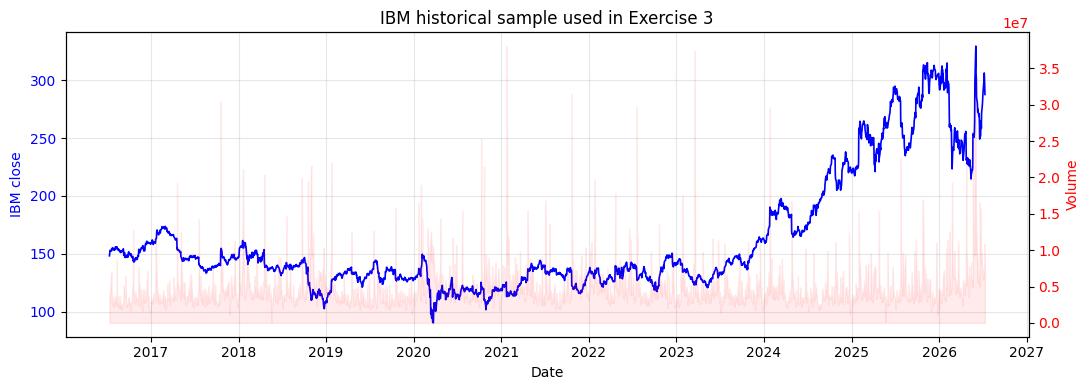

In [4]:
fig, ax_price = plt.subplots(figsize=(11, 4))

ax_price.plot(ibm["Date"], ibm[PRICE_COLUMN], color="blue", linewidth=1.2)
ax_price.set_xlabel("Date")
ax_price.set_ylabel("IBM close", color="blue")
ax_price.tick_params(axis="y", labelcolor="blue")
ax_price.grid(alpha=0.3)

if VOLUME_COLUMN in ibm.columns:
    ax_volume = ax_price.twinx()
    ax_volume.fill_between(
        ibm["Date"],
        pd.to_numeric(ibm[VOLUME_COLUMN], errors="coerce").fillna(0),
        color="red",
        alpha=0.08,
    )
    ax_volume.set_ylabel("Volume", color="red")
    ax_volume.tick_params(axis="y", labelcolor="red")

ax_price.set_title("IBM historical sample used in Exercise 3")
fig.tight_layout()
plt.show()


## Historical option paths and causal volatility

Each path consists of 21 consecutive prices, normalized by its initial price:

$$\widetilde S_{t_n}=S_{t_n}/S_{t_0}.$$

Volatility at time $t_n$ uses only the 20 returns observable up to that time:

$$
\widehat\sigma_{t_n}=\sqrt{250}\,
\operatorname{sd}(r_{n-19},\ldots,r_n).
$$

The train, validation, and test intervals are chronological, and option windows
are not allowed to cross a split boundary.


In [5]:
prices = ibm[PRICE_COLUMN].to_numpy(dtype=np.float64)
dates = ibm["Date"].to_numpy()

rolling_volatility = (
    pd.Series(np.log(prices))
    .diff()
    .rolling(VOL_WINDOW)
    .std(ddof=1)
    .to_numpy()
    * np.sqrt(TRADING_DAYS)
)

n_observations = len(prices)
train_end = int(TRAIN_FRACTION * n_observations)
validation_end = int(
    (TRAIN_FRACTION + VALIDATION_FRACTION) * n_observations
)


def build_pool(start_index, end_index):
    first_start = max(start_index, VOL_WINDOW)
    starts = np.arange(first_start, end_index - N_STEPS)

    if starts.size == 0:
        raise ValueError("A chronological split contains no complete option windows.")

    price_windows = np.lib.stride_tricks.sliding_window_view(
        prices,
        N_STEPS + 1,
    )[starts]
    volatility_windows = np.lib.stride_tricks.sliding_window_view(
        rolling_volatility,
        N_STEPS + 1,
    )[starts]

    valid = np.isfinite(volatility_windows).all(axis=1)
    starts = starts[valid]
    price_windows = price_windows[valid]
    volatility_windows = volatility_windows[valid]

    normalized_spot = price_windows / price_windows[:, :1]

    return {
        "spot": normalized_spot.astype(np.float32),
        "volatility": volatility_windows.astype(np.float32),
        "start_dates": dates[starts],
        "end_dates": dates[starts + N_STEPS],
    }


pools = {
    "train": build_pool(0, train_end),
    "validation": build_pool(train_end, validation_end),
    "test": build_pool(validation_end, n_observations),
}


In [6]:
split_rows = []

for name, pool in pools.items():
    hit = pool["spot"].max(axis=1) >= B
    split_rows.append(
        {
            "Split": name.title(),
            "Windows": len(pool["spot"]),
            "First start": pd.Timestamp(pool["start_dates"][0]).date(),
            "Last maturity": pd.Timestamp(pool["end_dates"][-1]).date(),
            "Mean initial vol": pool["volatility"][:, 0].mean(),
            "Barrier-hit rate": hit.mean(),
        }
    )

split_summary = pd.DataFrame(split_rows).set_index("Split")

with pd.option_context("display.float_format", "{:.4f}".format):
    display(split_summary)

test_hit_rate = split_summary.loc["Test", "Barrier-hit rate"]
if test_hit_rate < 0.02:
    warnings.warn(
        f"Only {test_hit_rate:.2%} of test windows hit B={B:.1f}. "
        "Barrier-conditioned conclusions will be statistically weak."
    )


,Windows,First start,Last maturity,Mean initial vol,Barrier-hit rate
Split,,,,,
Train,1719,2016-08-08,2023-07-06,0.2193,0.0047
Validation,357,2023-07-07,2025-01-03,0.1918,0.0000
Test,358,2025-01-06,2026-07-10,0.3314,0.0670


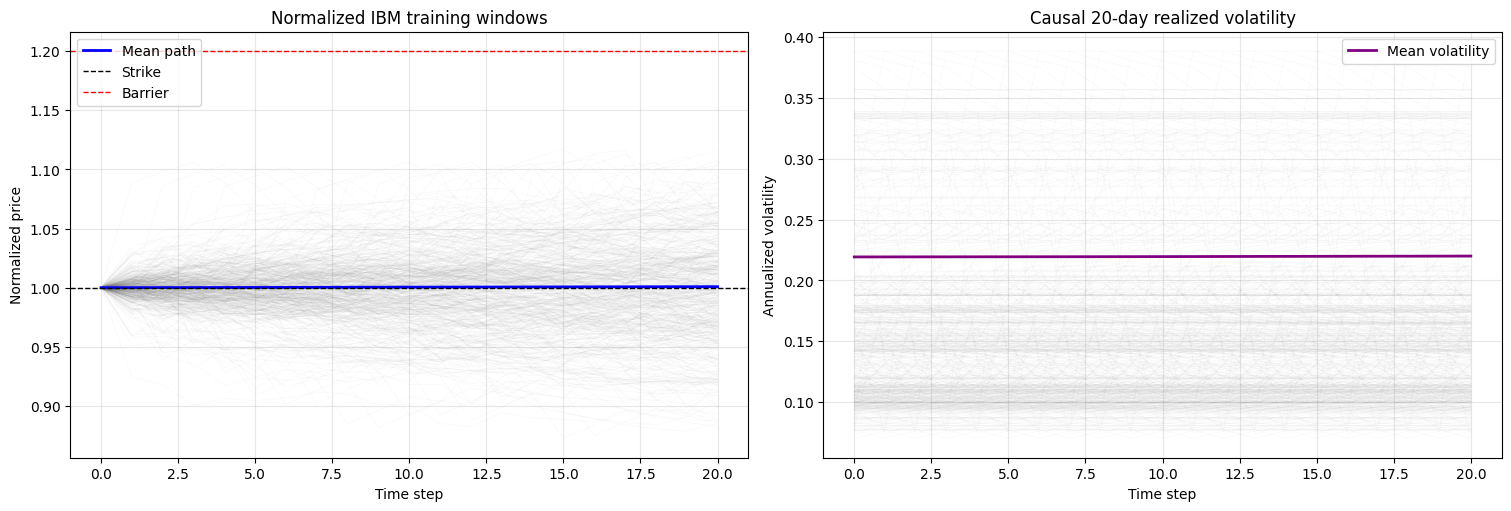

In [7]:
n_path_plot = min(N_PLOT, len(pools["train"]["spot"]))
time_steps = np.arange(N_STEPS + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

for path in pools["train"]["spot"][:n_path_plot]:
    axes[0].plot(time_steps, path, color="gray", alpha=0.05, linewidth=0.5)

axes[0].plot(
    time_steps,
    pools["train"]["spot"].mean(axis=0),
    color="blue",
    linewidth=2,
    label="Mean path",
)
axes[0].axhline(K, color="black", linestyle="--", linewidth=1, label="Strike")
axes[0].axhline(B, color="red", linestyle="--", linewidth=1, label="Barrier")
axes[0].set_title("Normalized IBM training windows")
axes[0].set_xlabel("Time step")
axes[0].set_ylabel("Normalized price")
axes[0].grid(alpha=0.3)
axes[0].legend(loc="upper left")

for path in pools["train"]["volatility"][:n_path_plot]:
    axes[1].plot(time_steps, path, color="gray", alpha=0.05, linewidth=0.5)

axes[1].plot(
    time_steps,
    pools["train"]["volatility"].mean(axis=0),
    color="purple",
    linewidth=2,
    label="Mean volatility",
)
axes[1].set_title("Causal 20-day realized volatility")
axes[1].set_xlabel("Time step")
axes[1].set_ylabel("Annualized volatility")
axes[1].grid(alpha=0.3)
axes[1].legend(loc="upper right")

plt.show()


## A historical primary instrument inside PFHedge

`HistoricalStock` replaces stochastic simulation by sampling historical windows.
During `Hedger.fit`, gradient-enabled calls draw from the training pool and
validation calls draw from the chronological validation pool. Test evaluation
loads every held-out test window exactly once.

The instrument still exposes the standard PFHedge `spot`, `volatility`, `variance`,
`dt`, and `cost` interface, so native features, P&L accounting, and pricing remain
available.


In [8]:
class HistoricalStock(BasePrimary):
    def __init__(
        self,
        pools,
        cost=0.0,
        dt=1 / 250,
        dtype=None,
        device=None,
    ):
        super().__init__()

        expected = {"train", "validation", "test"}
        if set(pools) != expected:
            raise ValueError(f"pools must have keys {sorted(expected)}")

        self.cost = float(cost)
        self.dt = float(dt)
        self.sampling_mode = "auto"

        self._spot_pools = {
            name: torch.as_tensor(pool["spot"], dtype=torch.get_default_dtype())
            .contiguous()
            .cpu()
            for name, pool in pools.items()
        }
        self._volatility_pools = {
            name: torch.as_tensor(
                pool["volatility"],
                dtype=torch.get_default_dtype(),
            )
            .contiguous()
            .cpu()
            for name, pool in pools.items()
        }

        lengths = {
            tensor.shape[-1]
            for tensor in self._spot_pools.values()
        }
        if len(lengths) != 1:
            raise ValueError("All historical pools must use the same horizon.")

        for name in expected:
            if self._spot_pools[name].shape != self._volatility_pools[name].shape:
                raise ValueError(f"Spot and volatility shapes differ in {name}.")

        self.to(dtype=dtype, device=device)

    @property
    def default_init_state(self):
        return (1.0,)

    @property
    def volatility(self):
        return self.get_buffer("volatility_path")

    @property
    def variance(self):
        return self.volatility.square()

    def use_pool(self, name):
        if name not in {"auto", "train", "validation", "test"}:
            raise ValueError("name must be auto, train, validation, or test")
        self.sampling_mode = name
        return self

    def _resolved_pool(self):
        if self.sampling_mode == "auto":
            return "train" if torch.is_grad_enabled() else "validation"
        return self.sampling_mode

    def _register_selection(self, pool_name, indices):
        spot = self._spot_pools[pool_name].index_select(0, indices)
        volatility = self._volatility_pools[pool_name].index_select(0, indices)

        self.register_buffer("spot", spot)
        self.register_buffer("volatility_path", volatility)

    def load_pool(self, name):
        if name not in self._spot_pools:
            raise ValueError(f"Unknown historical pool: {name}")

        self.sampling_mode = name
        indices = torch.arange(len(self._spot_pools[name]))
        self._register_selection(name, indices)
        return self

    def simulate(self, n_paths=1, time_horizon=20 / 250, init_state=None):
        n_steps = ceil(time_horizon / self.dt + 1)
        pool_name = self._resolved_pool()
        spot_pool = self._spot_pools[pool_name]

        if n_steps != spot_pool.shape[-1]:
            raise ValueError(
                f"Requested {n_steps} time points, but historical windows "
                f"contain {spot_pool.shape[-1]}."
            )

        if self.sampling_mode != "auto" and n_paths == len(spot_pool):
            indices = torch.arange(len(spot_pool))
        else:
            indices = torch.randint(len(spot_pool), size=(n_paths,))

        self._register_selection(pool_name, indices)

    def extra_repr(self):
        return f"cost={self.cost:.4g}, dt={self.dt:.4g}, mode={self.sampling_mode}"


In [9]:
def knockout_clause(derivative, payoff):
    maximum = derivative.ul().spot.max(dim=-1).values
    return torch.where(maximum < B, payoff, torch.zeros_like(payoff))


def make_derivative(cost):
    stock = HistoricalStock(
        pools=pools,
        cost=cost,
        dt=DT,
        dtype=torch.get_default_dtype(),
        device=DEVICE,
    )
    derivative = EuropeanOption(stock, strike=K, maturity=MATURITY)
    derivative.add_clause("up_and_out", knockout_clause)
    derivative.to(dtype=torch.get_default_dtype(), device=DEVICE)
    return derivative


derivative_no_cost = make_derivative(cost=0.0)
derivative_cost = make_derivative(cost=TRANSACTION_COST)

print(derivative_no_cost)
print(derivative_cost)


EuropeanOption(
  strike=1., maturity=0.0800
  clauses=['up_and_out']
  (underlier): HistoricalStock(cost=0, dt=0.004, mode=auto)
)
EuropeanOption(
  strike=1., maturity=0.0800
  clauses=['up_and_out']
  (underlier): HistoricalStock(cost=0.001, dt=0.004, mode=auto)
)


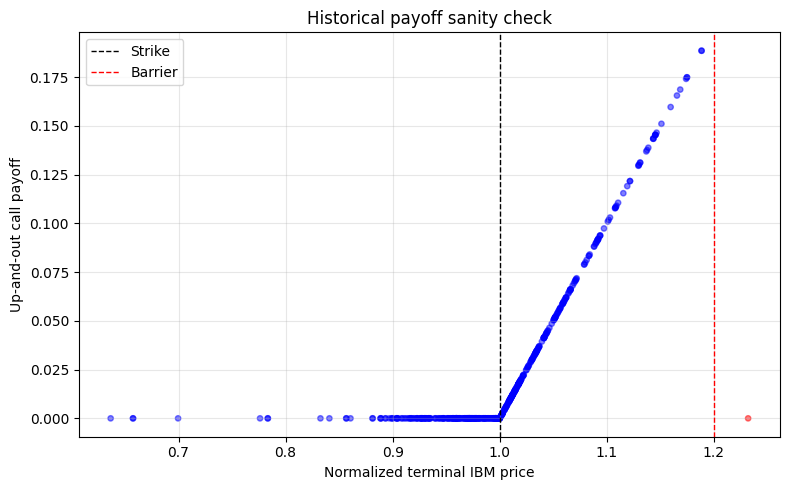

In [10]:
# Sanity check: knocked-out paths have zero payoff.
derivative_no_cost.ul().use_pool("train")
derivative_no_cost.simulate(n_paths=min(500, len(pools["train"]["spot"])))

sample_spot = derivative_no_cost.ul().spot.detach().cpu()
sample_payoff = derivative_no_cost.payoff().detach().cpu()
sample_hit = sample_spot.max(dim=-1).values >= B

assert torch.all(sample_payoff[sample_hit] == 0)

plt.figure(figsize=(8, 5))
plt.scatter(
    sample_spot[:, -1],
    sample_payoff,
    c=np.where(sample_hit.numpy(), "red", "blue"),
    alpha=0.5,
    s=15,
)
plt.axvline(K, color="black", linestyle="--", linewidth=1, label="Strike")
plt.axvline(B, color="red", linestyle="--", linewidth=1, label="Barrier")
plt.xlabel("Normalized terminal IBM price")
plt.ylabel("Up-and-out call payoff")
plt.title("Historical payoff sanity check")
plt.grid(alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


## Neural hedgers

Both models use the same three-layer, 16-unit MLP architecture as the previous
notebook. The barrier flag is supplied to both models. `prev_hedge` adds only one
scalar feature, but makes the second model recurrent and therefore prevents
PFHedge from evaluating all time steps in one vectorized call.


In [11]:
def model_inputs(include_prev_hedge=False):
    inputs = [
        "log_moneyness",
        "expiry_time",
        "volatility",
        Barrier(B, up=True),
    ]
    if include_prev_hedge:
        inputs.append("prev_hedge")
    return inputs


torch.manual_seed(MODEL_SEED)
model1 = MultiLayerPerceptron(
    in_features=4,
    n_units=16,
    n_layers=3,
)
model1c = deepcopy(model1)

torch.manual_seed(MODEL_SEED)
model1p = MultiLayerPerceptron(
    in_features=5,
    n_units=16,
    n_layers=3,
)
model1pc = deepcopy(model1p)

hedger1 = Hedger(
    model1,
    inputs=model_inputs(include_prev_hedge=False),
    criterion=EntropicRiskMeasure(a=1.0),
).to(DEVICE)
hedger1p = Hedger(
    model1p,
    inputs=model_inputs(include_prev_hedge=True),
    criterion=EntropicRiskMeasure(a=1.0),
).to(DEVICE)
hedger1c = Hedger(
    model1c,
    inputs=model_inputs(include_prev_hedge=False),
    criterion=EntropicRiskMeasure(a=1.0),
).to(DEVICE)
hedger1pc = Hedger(
    model1pc,
    inputs=model_inputs(include_prev_hedge=True),
    criterion=EntropicRiskMeasure(a=1.0),
).to(DEVICE)

print("State-feature model, no cost")
print(hedger1)
print("\nState-feature + previous hedge model, no cost")
print(hedger1p)
print("\nState-feature model, proportional cost")
print(hedger1c)
print("\nState-feature + previous hedge model, proportional cost")
print(hedger1pc)


State-feature model, no cost
Hedger(
  inputs=['log_moneyness', 'expiry_time', 'volatility', 'barrier']
  (model): MultiLayerPerceptron(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Identity()
  )
  (criterion): EntropicRiskMeasure()
)

State-feature + previous hedge model, no cost
Hedger(
  inputs=['log_moneyness', 'expiry_time', 'volatility', 'barrier', 'prev_hedge']
  (model): MultiLayerPerceptron(
    (0): Linear(in_features=5, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Identity()
  )
  (criterion): EntropicRiskMeasure(

## Training

There are two architectures and two cost regimes, hence four independent fits.
The cost and no-cost versions of a given architecture start from identical
weights. Resetting the sampling seed before every fit also gives each model the
same sequence of historical training and validation windows.


In [12]:
def fit_model(label, hedger, derivative):
    derivative.ul().use_pool("auto")

    torch.manual_seed(TRAINING_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(TRAINING_SEED)

    start = perf_counter()
    history = hedger.fit(
        derivative,
        n_epochs=N_EPOCHS,
        n_paths=N_PATHS,
        n_times=N_TIMES,
        validation=True,
        verbose=True,
        tqdm_kwargs={"leave": False},
    )
    elapsed = perf_counter() - start

    print(f"{label}: {elapsed:.2f} seconds")
    return history, elapsed


In [13]:
history1, training_time1 = fit_model(
    "State features, no cost",
    hedger1,
    derivative_no_cost,
)


State features, no cost: 13.87 seconds


In [14]:
history1p, training_time1p = fit_model(
    "State features + previous hedge, no cost",
    hedger1p,
    derivative_no_cost,
)


State features + previous hedge, no cost: 9.20 seconds


In [15]:
history1c, training_time1c = fit_model(
    "State features, proportional cost",
    hedger1c,
    derivative_cost,
)


State features, proportional cost: 2.04 seconds


In [16]:
history1pc, training_time1pc = fit_model(
    "State features + previous hedge, proportional cost",
    hedger1pc,
    derivative_cost,
)


State features + previous hedge, proportional cost: 9.60 seconds


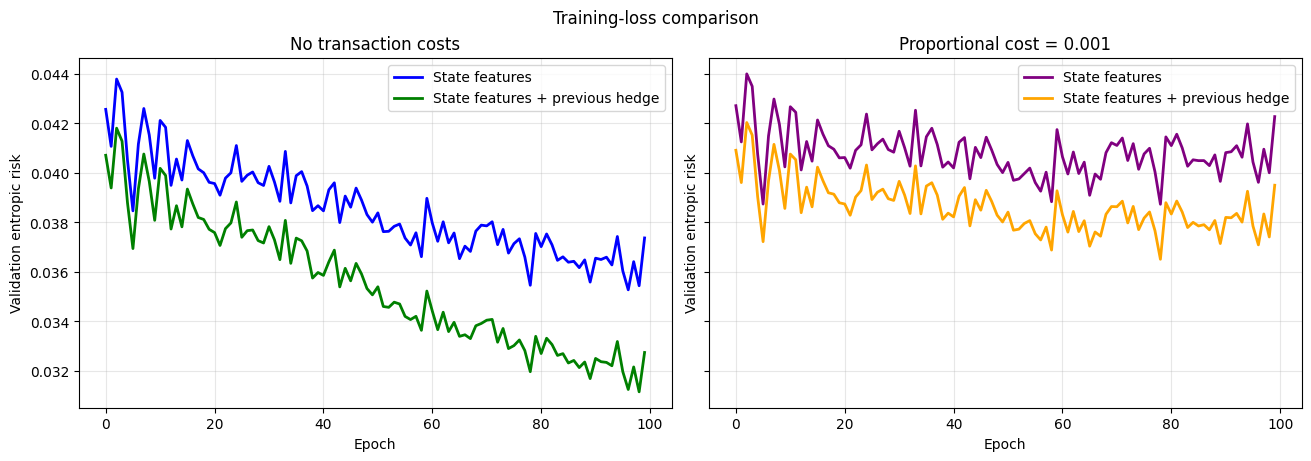

In [17]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

axes[0].plot(history1, color="blue", linewidth=2, label="State features")
axes[0].plot(
    history1p,
    color="green",
    linewidth=2,
    label="State features + previous hedge",
)
axes[0].set_title("No transaction costs")

axes[1].plot(history1c, color="purple", linewidth=2, label="State features")
axes[1].plot(
    history1pc,
    color="orange",
    linewidth=2,
    label="State features + previous hedge",
)
axes[1].set_title(f"Proportional cost = {TRANSACTION_COST:.4g}")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation entropic risk")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right")

fig.suptitle("Training-loss comparison")
plt.show()


## Held-out historical comparison

Every model is now evaluated on exactly the same chronological test windows.
`compute_pl` excludes the option premium. We therefore add each model's empirical
entropic premium before plotting the terminal P&L.

Turnover uses the actual trades

$$q_0=h_0,\qquad q_n=h_n-h_{n-1},$$

which is also the quantity used by PFHedge's proportional transaction cost.


In [18]:
def evaluate_hedger(label, hedger, derivative, cost_rate, training_time):
    underlier = derivative.ul()
    underlier.use_pool("test")
    n_test = len(pools["test"]["spot"])

    with torch.no_grad():
        premium = hedger.price(derivative, n_paths=n_test).detach().cpu()

        # Reloading guarantees the same ordered test paths after price().
        underlier.load_pool("test")

        hedge = hedger.compute_hedge(derivative)[:, 0, :].detach().cpu()
        raw_pnl = hedger.compute_pl(derivative).detach().cpu()
        payoff = derivative.payoff().detach().cpu()
        spot = underlier.spot.detach().cpu()
        volatility = underlier.volatility.detach().cpu()

    pnl_after_premium = raw_pnl + premium
    trades = torch.cat(
        [hedge[:, :1], hedge[:, 1:] - hedge[:, :-1]],
        dim=1,
    )
    turnover = trades.abs().sum(dim=1)
    transaction_cost = cost_rate * (trades.abs() * spot).sum(dim=1)
    material_trades = (trades.abs() > 1e-3).sum(dim=1)
    barrier_hit = spot.max(dim=1).values >= B

    volatility_scale = (
        volatility[:, 0] * np.sqrt(MATURITY)
    ).clamp_min(1e-6)
    scaled_pnl = pnl_after_premium / volatility_scale

    return {
        "label": label,
        "premium": premium,
        "raw_pnl": raw_pnl,
        "pnl": pnl_after_premium,
        "scaled_pnl": scaled_pnl,
        "payoff": payoff,
        "hedge": hedge,
        "trades": trades,
        "turnover": turnover,
        "transaction_cost": transaction_cost,
        "material_trades": material_trades,
        "barrier_hit": barrier_hit,
        "spot": spot,
        "volatility": volatility,
        "training_time": training_time,
    }


results = [
    evaluate_hedger(
        "State, no cost",
        hedger1,
        derivative_no_cost,
        0.0,
        training_time1,
    ),
    evaluate_hedger(
        "State + previous hedge, no cost",
        hedger1p,
        derivative_no_cost,
        0.0,
        training_time1p,
    ),
    evaluate_hedger(
        "State, proportional cost",
        hedger1c,
        derivative_cost,
        TRANSACTION_COST,
        training_time1c,
    ),
    evaluate_hedger(
        "State + previous hedge, proportional cost",
        hedger1pc,
        derivative_cost,
        TRANSACTION_COST,
        training_time1pc,
    ),
]

COLORS = {
    "State, no cost": "blue",
    "State + previous hedge, no cost": "green",
    "State, proportional cost": "purple",
    "State + previous hedge, proportional cost": "orange",
}


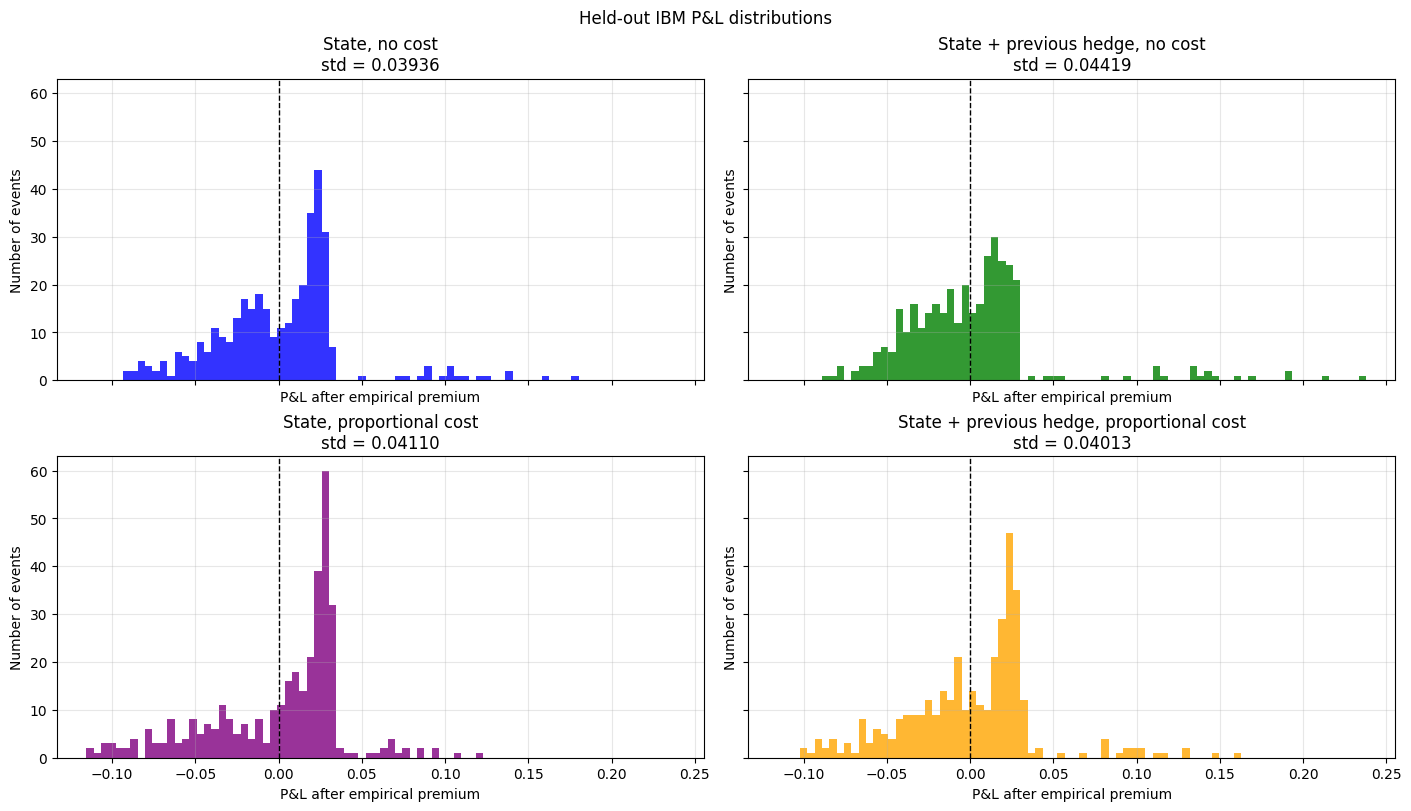

In [19]:
all_pnl = torch.cat([result["pnl"] for result in results])
xmin, xmax = all_pnl.min().item(), all_pnl.max().item()

if np.isclose(xmin, xmax):
    xmin, xmax = xmin - 1e-3, xmax + 1e-3

bins = np.linspace(xmin, xmax, 81)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 8),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for ax, result in zip(axes.flat, results):
    pnl = result["pnl"]
    color = COLORS[result["label"]]

    ax.hist(pnl.numpy(), bins=bins, color=color, alpha=0.8)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{result['label']}\nstd = {pnl.std():.5f}")
    ax.set_xlabel("P&L after empirical premium")
    ax.set_ylabel("Number of events")
    ax.grid(alpha=0.3)

fig.suptitle("Held-out IBM P&L distributions")
plt.show()


In [20]:
def lower_expected_shortfall(values, probability=0.05):
    threshold = torch.quantile(values, probability)
    return values[values <= threshold].mean()


print("Empirical entropic premiums on the held-out IBM windows")
for result in results:
    print(f"{result['label']:<44} {result['premium'].item():.6f}")

metric_rows = []

for result in results:
    pnl = result["pnl"]
    metric_rows.append(
        {
            "Model": result["label"],
            "Premium": result["premium"].item(),
            "Mean P&L": pnl.mean().item(),
            "P&L std": pnl.std().item(),
            "5% quantile": torch.quantile(pnl, 0.05).item(),
            "ES 5%": lower_expected_shortfall(pnl).item(),
            "Vol-scaled std": result["scaled_pnl"].std().item(),
            "Mean turnover": result["turnover"].mean().item(),
            "Mean native cost": result["transaction_cost"].mean().item(),
            "Mean material trades": result["material_trades"].float().mean().item(),
            "Training seconds": result["training_time"],
        }
    )

metrics = pd.DataFrame(metric_rows).set_index("Model")

with pd.option_context("display.float_format", "{:.6f}".format):
    display(metrics)


Empirical entropic premiums on the held-out IBM windows
State, no cost                               0.030846
State + previous hedge, no cost              0.028472
State, proportional cost                     0.033337
State + previous hedge, proportional cost    0.031754


,Premium,Mean P&L,P&L std,5% quantile,ES 5%,Vol-scaled std,Mean turnover,Mean native cost,Mean material trades,Training seconds
Model,,,,,,,,,,
"State, no cost",0.030846,0.000765,0.039361,-0.061997,-0.077664,0.542826,0.361158,0.000000,6.209497,13.869112
"State + previous hedge, no cost",0.028472,0.000946,0.044194,-0.054397,-0.066506,0.542224,0.525416,0.000000,7.357542,9.203844
"State, proportional cost",0.033337,0.000850,0.041097,-0.078785,-0.097758,0.617401,0.241508,0.000242,8.960894,2.038105
"State + previous hedge, proportional cost",0.031754,0.000800,0.040131,-0.066976,-0.084925,0.569236,0.314644,0.000314,4.787710,9.598457


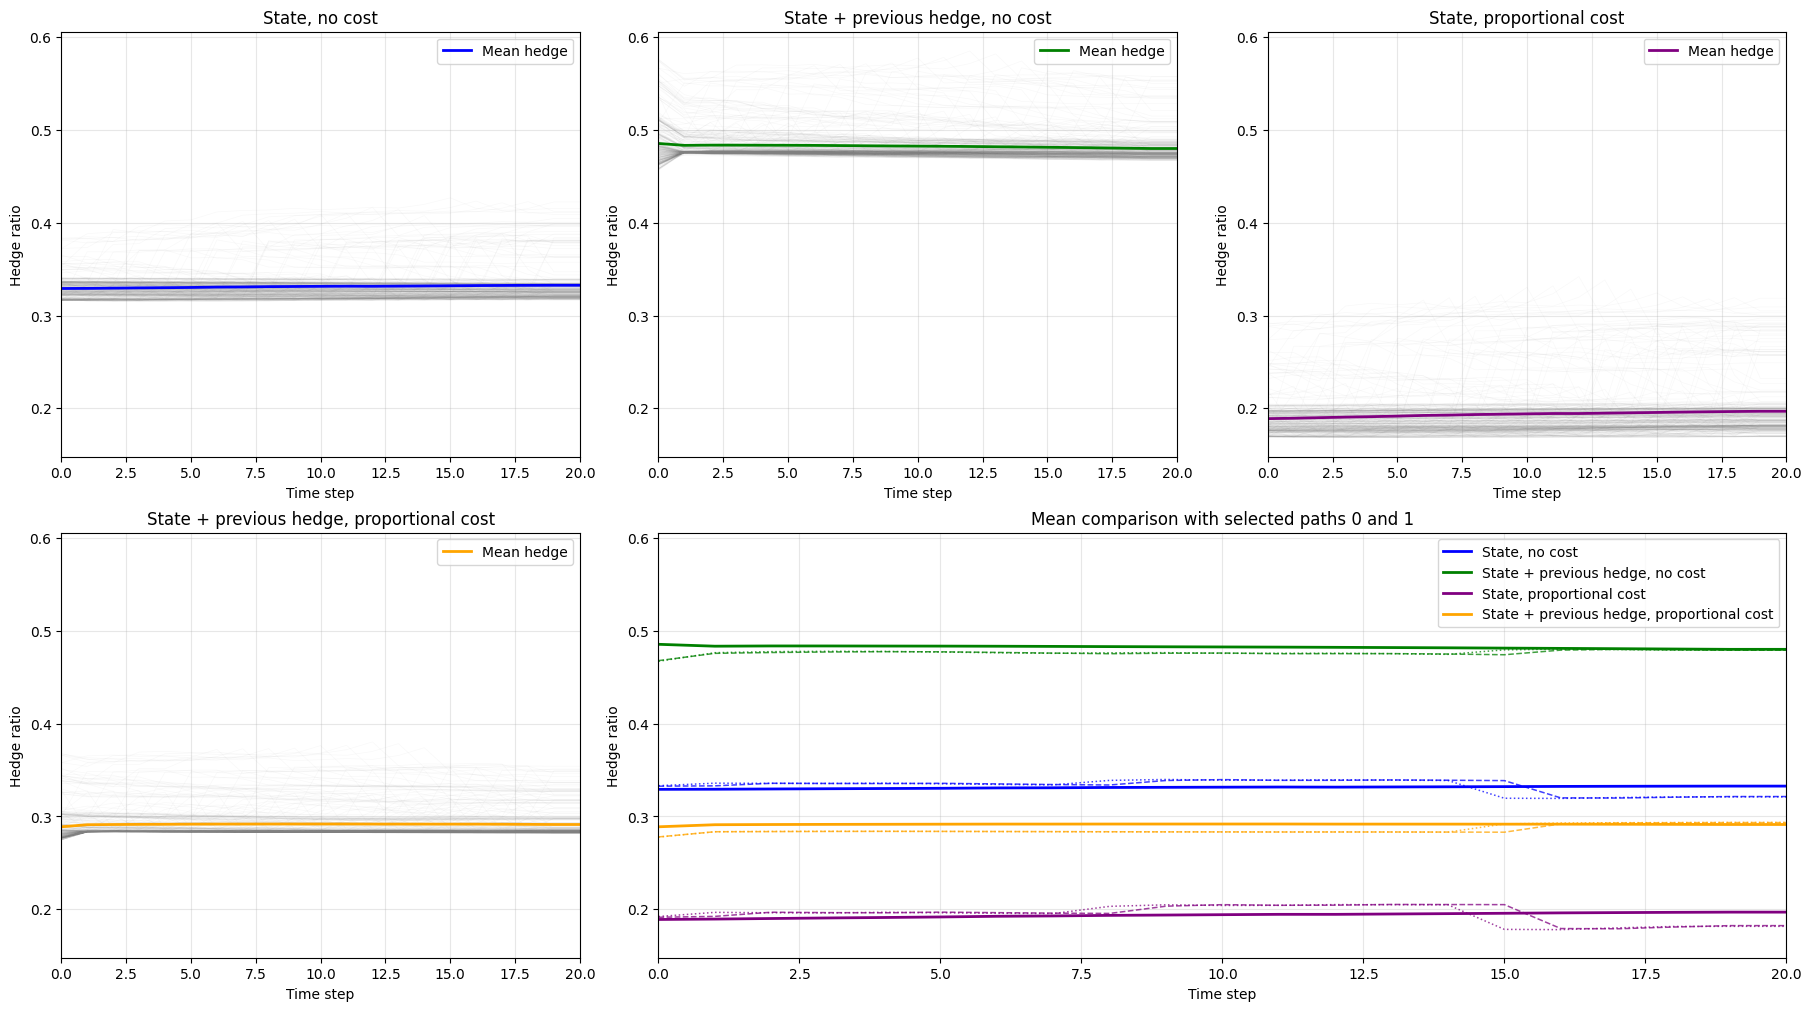

In [21]:
time = np.arange(N_STEPS + 1)
n_plot = min(N_PLOT, len(results[0]["hedge"]))

fig = plt.figure(figsize=(18, 10), constrained_layout=True)
gs = fig.add_gridspec(2, 3)

first_ax = fig.add_subplot(gs[0, 0])
individual_axes = [
    first_ax,
    fig.add_subplot(gs[0, 1], sharex=first_ax, sharey=first_ax),
    fig.add_subplot(gs[0, 2], sharex=first_ax, sharey=first_ax),
    fig.add_subplot(gs[1, 0], sharex=first_ax, sharey=first_ax),
]

for ax, result in zip(individual_axes, results):
    hedge = result["hedge"]
    mean_hedge = hedge.mean(dim=0)

    for path in hedge[:n_plot]:
        ax.plot(time, path, color="gray", alpha=0.05, linewidth=0.5)

    ax.plot(
        time,
        mean_hedge,
        color=COLORS[result["label"]],
        linewidth=2,
        label="Mean hedge",
    )
    ax.set_title(result["label"])
    ax.set_xlabel("Time step")
    ax.set_ylabel("Hedge ratio")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right")

comparison_ax = fig.add_subplot(
    gs[1, 1:],
    sharex=first_ax,
    sharey=first_ax,
)

for result in results:
    comparison_ax.plot(
        time,
        result["hedge"].mean(dim=0),
        color=COLORS[result["label"]],
        linewidth=2,
        label=result["label"],
    )

selected_paths = range(min(2, len(results[0]["hedge"])))
selected_styles = ["--", ":"]

for path, style in zip(selected_paths, selected_styles):
    for result in results:
        comparison_ax.plot(
            time,
            result["hedge"][path],
            color=COLORS[result["label"]],
            linestyle=style,
            linewidth=1.1,
            alpha=0.75,
        )

comparison_ax.set_title("Mean comparison with selected paths 0 and 1")
comparison_ax.set_xlabel("Time step")
comparison_ax.set_ylabel("Hedge ratio")
comparison_ax.grid(alpha=0.3)
comparison_ax.legend(loc="upper right")

first_ax.set_xlim(0, N_STEPS)
plt.show()


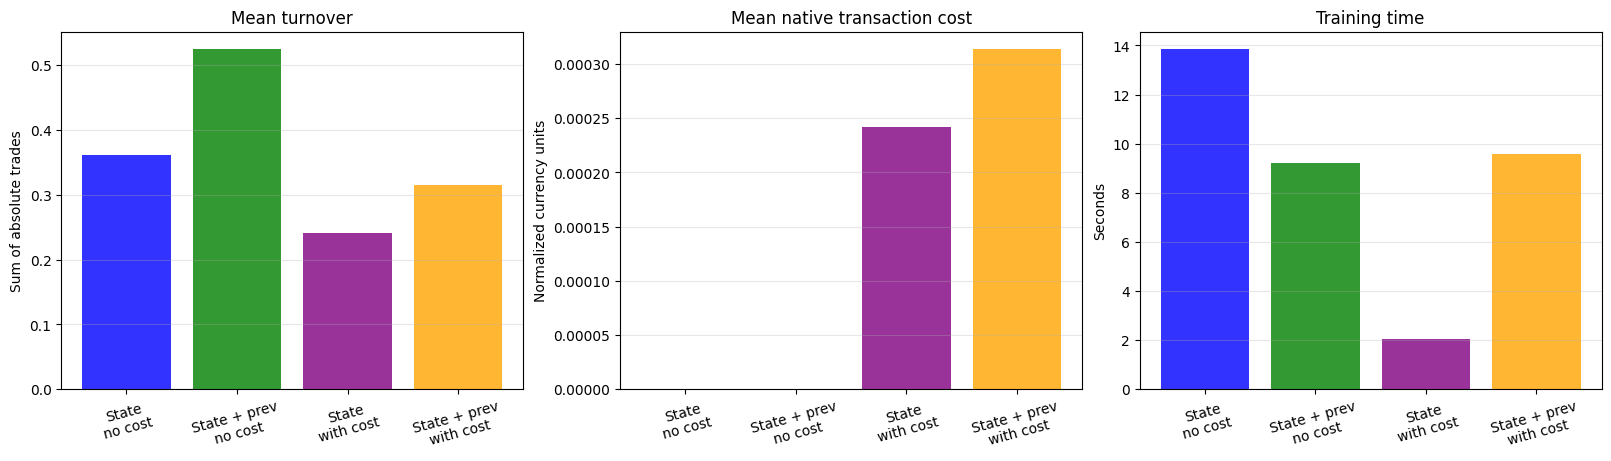

In [22]:
labels = [result["label"] for result in results]
colors = [COLORS[label] for label in labels]
short_labels = [
    "State\nno cost",
    "State + prev\nno cost",
    "State\nwith cost",
    "State + prev\nwith cost",
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

axes[0].bar(
    short_labels,
    [result["turnover"].mean().item() for result in results],
    color=colors,
    alpha=0.8,
)
axes[0].set_title("Mean turnover")
axes[0].set_ylabel("Sum of absolute trades")

axes[1].bar(
    short_labels,
    [result["transaction_cost"].mean().item() for result in results],
    color=colors,
    alpha=0.8,
)
axes[1].set_title("Mean native transaction cost")
axes[1].set_ylabel("Normalized currency units")

axes[2].bar(
    short_labels,
    [result["training_time"] for result in results],
    color=colors,
    alpha=0.8,
)
axes[2].set_title("Training time")
axes[2].set_ylabel("Seconds")

for ax in axes:
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", labelrotation=15)

plt.show()


In [23]:
conditional_rows = []

for result in results:
    for hit_value, state_name in [(False, "Alive"), (True, "Knocked out")]:
        mask = result["barrier_hit"] == hit_value

        if mask.any():
            conditional_rows.append(
                {
                    "Model": result["label"],
                    "Barrier state": state_name,
                    "Paths": int(mask.sum()),
                    "Mean P&L": result["pnl"][mask].mean().item(),
                    "P&L std": result["pnl"][mask].std().item(),
                    "Mean turnover": result["turnover"][mask].mean().item(),
                }
            )
        else:
            conditional_rows.append(
                {
                    "Model": result["label"],
                    "Barrier state": state_name,
                    "Paths": 0,
                    "Mean P&L": np.nan,
                    "P&L std": np.nan,
                    "Mean turnover": np.nan,
                }
            )

conditional_metrics = pd.DataFrame(conditional_rows).set_index(
    ["Model", "Barrier state"]
)

with pd.option_context("display.float_format", "{:.6f}".format):
    display(conditional_metrics)


Paths  Mean P&L  \
Model                                     Barrier state                    
State, no cost                            Alive            334 -0.005602   
                                          Knocked out       24  0.089371   
State + previous hedge, no cost           Alive            334 -0.007907   
                                          Knocked out       24  0.124153   
State, proportional cost                  Alive            334 -0.003507   
                                          Knocked out       24  0.061475   
State + previous hedge, proportional cost Alive            334 -0.005411   
                                          Knocked out       24  0.087229   

                                                         P&L std  \
Model                                     Barrier state            
State, no cost                            Alive         0.030228   
                                          Knocked out   0.045130   
State + previous hedge, no cost           Alive         0.026634   
                                          Knocked out   0.055377   
State, proportional cost                  Alive         0.038201   
                                          Knocked out   0.031244   
State + previous hedge, proportional cost Alive         0.032517   
                                          Knocked out   0.036523   

                                                         Mean turnover  
Model                                     Barrier state                 
State, no cost                            Alive               0.357121  
                                          Knocked out         0.417332  
State + previous hedge, no cost           Alive               0.524006  
                                          Knocked out         0.545046  
State, proportional cost                  Alive               0.236412  
                                          Knocked out         0.312420  
State + previous hedge, proportional cost Alive               0.312921  
                                          Knocked out         0.338613

In [24]:
def percentage_change(new, old):
    if np.isclose(old, 0.0):
        return np.nan
    return 100 * (new / old - 1)


comparisons = [
    ("No cost", results[0], results[1]),
    ("Proportional cost", results[2], results[3]),
]

for regime, state_model, recurrent_model in comparisons:
    std_change = percentage_change(
        recurrent_model["pnl"].std().item(),
        state_model["pnl"].std().item(),
    )
    turnover_change = percentage_change(
        recurrent_model["turnover"].mean().item(),
        state_model["turnover"].mean().item(),
    )
    speed_ratio = (
        recurrent_model["training_time"] / state_model["training_time"]
    )

    print(regime)
    print(f"  P&L standard-deviation change with prev_hedge: {std_change:+.2f}%")
    print(f"  Turnover change with prev_hedge:              {turnover_change:+.2f}%")
    print(f"  Training-time ratio:                          {speed_ratio:.2f}x")

print(f"\nHeld-out barrier-hit rate: {results[0]['barrier_hit'].float().mean():.2%}")


No cost
  P&L standard-deviation change with prev_hedge: +12.28%
  Turnover change with prev_hedge:              +45.48%
  Training-time ratio:                          0.66x
Proportional cost
  P&L standard-deviation change with prev_hedge: -2.35%
  Turnover change with prev_hedge:              +30.28%
  Training-time ratio:                          4.71x

Held-out barrier-hit rate: 6.70%
